In [10]:
import polars as pl
import matplotlib.pyplot as plt

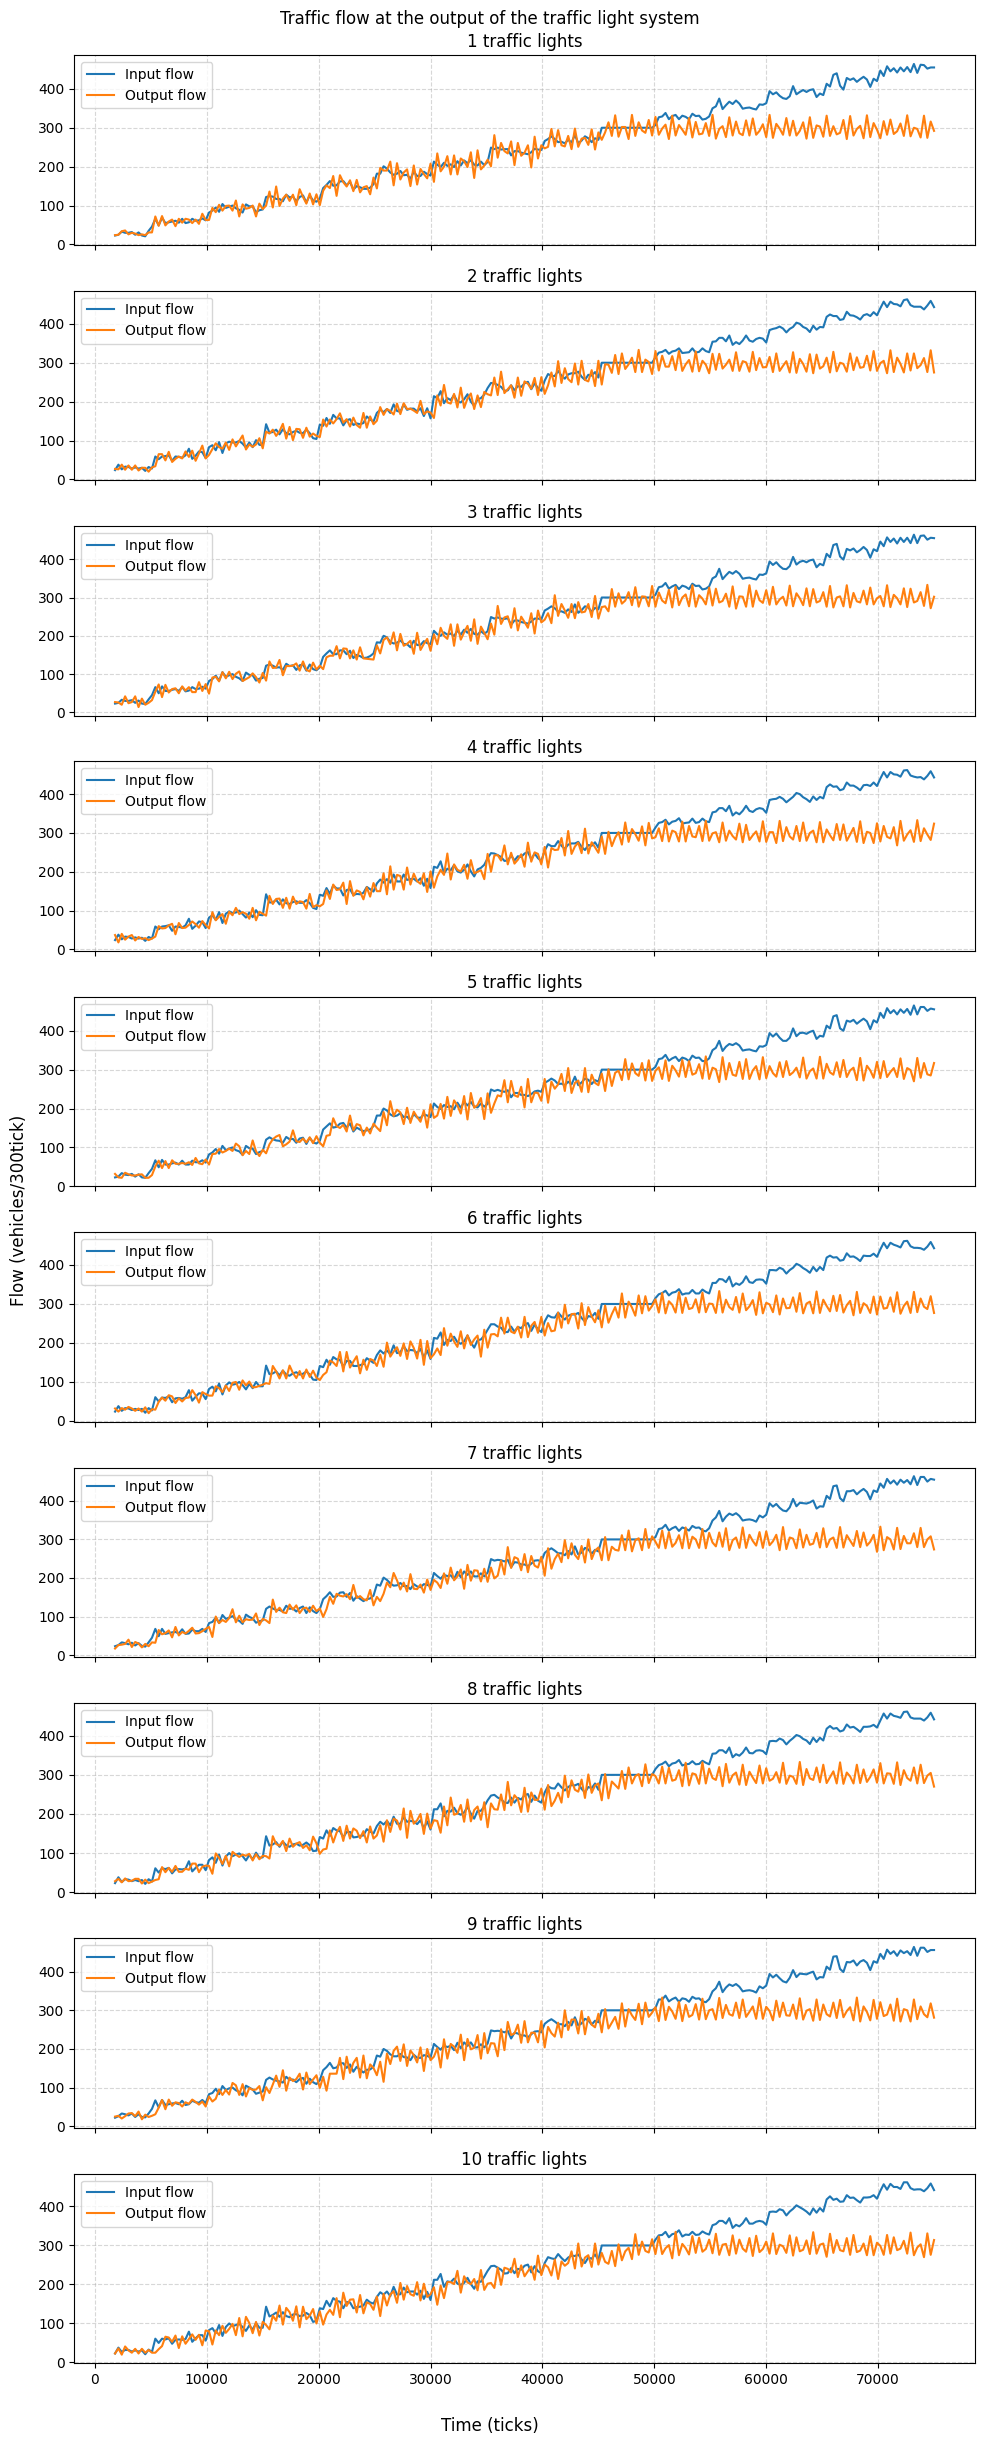

In [11]:
N_MAX = 10
SEED = 69

fig, ax = plt.subplots(nrows=N_MAX, ncols=1, sharex=True, figsize=(10, 2.5 * N_MAX))

for n in range(N_MAX):
    df = pl.read_csv(f"{SEED}_traffic_light_output_{n+1}.csv", separator=";")
    # drop first 5 rows
    df = df[5:]
    ax[n].plot(df["time"], df["input_flow"], label="Input flow")
    ax[n].plot(df["time"], df["output_flow"], label="Output flow")
    ax[n].set_title(f"{n+1} traffic lights")
    ax[n].legend(loc="upper left")
    ax[n].grid(ls="--", alpha=0.5)

fig.suptitle("Traffic flow at the output of the traffic light system")
fig.supxlabel("Time (ticks)")
fig.supylabel("Flow (vehicles/300tick)")
plt.tight_layout(rect=[0, 0.01, 1, 0.99])
plt.show()

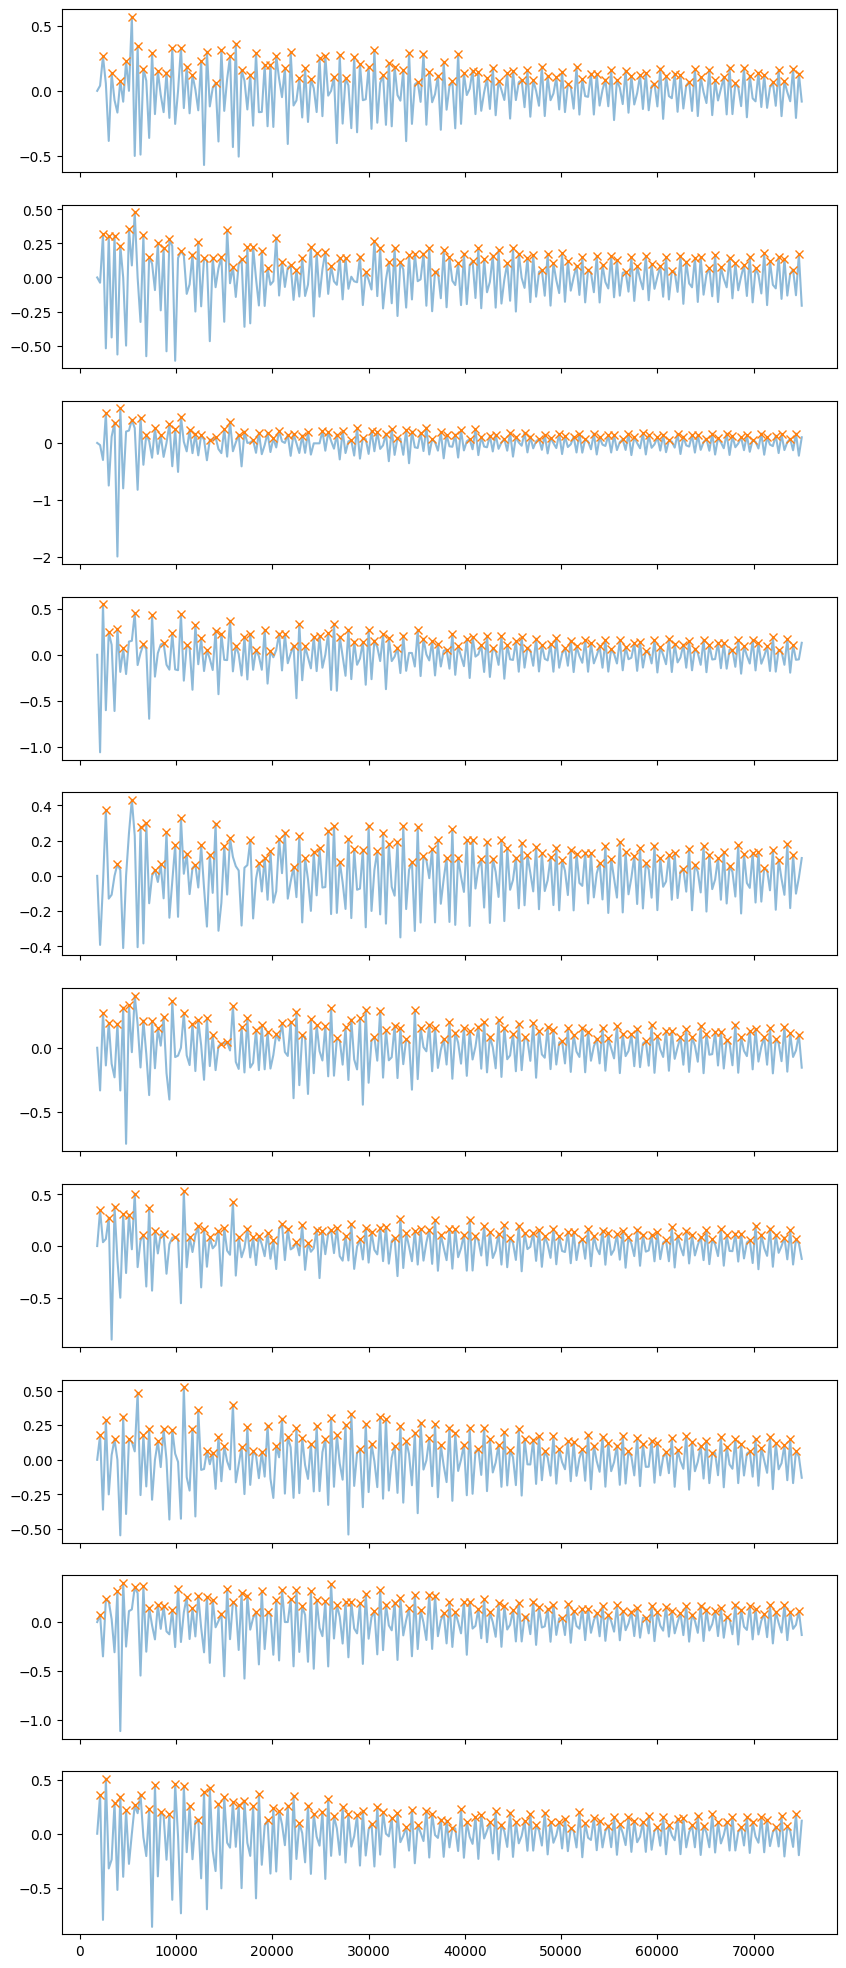

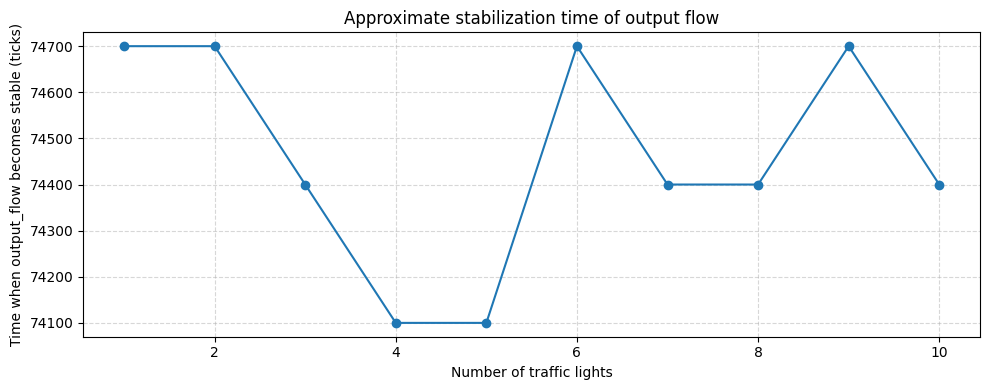

In [12]:
from scipy.signal import find_peaks

plateau_window = 5
plateau_tol = 10
stabilization_times = []

fig, ax = plt.subplots(nrows=N_MAX, ncols=1, sharex=True, figsize=(10, 2.5 * N_MAX))

for n in range(N_MAX):
    df = pl.read_csv(f"{SEED}_traffic_light_output_{n+1}.csv", separator=";").slice(5)
    output_flow = df["output_flow"].diff().to_numpy()
    output_flow[0] = 0.0  # fix NaN from diff()
    output_flow /= df["output_flow"].to_numpy()  # normalize to get relative changes
    times = df["time"].to_list()

    # Find peaks in the output flow to identify oscillations
    peaks, _ = find_peaks(output_flow, height=0.025)

    ax[n].plot(times, output_flow, label=f"TL {n+1} output_flow", alpha=0.5)
    ax[n].plot([times[i] for i in peaks], [output_flow[i] for i in peaks], "x", label="Peaks")

    # stabilization_time  should be the last peak
    stabilization_time = times[peaks[-1]] if len(peaks) > 0 else times[-1]

    stabilization_times.append(stabilization_time)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, N_MAX + 1), stabilization_times, marker="o")
ax.set_title("Approximate stabilization time of output flow")
ax.set_xlabel("Number of traffic lights")
ax.set_ylabel("Time when output_flow becomes stable (ticks)")
ax.grid(ls="--", alpha=0.5)
plt.tight_layout()
plt.show()